In [25]:
cd ~/code/StinoNL/transfer_carrousel

/home/stijn/code/StinoNL/transfer_carrousel


/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.base import BaseEstimator, TransformerMixin


In [27]:
# Load the dataset
df_first_dataset = pd.read_csv("complete_dataset/j_complete_dataset.csv")

# Show first rows
df_first_dataset.head()

,player_id,player_name,country_of_citizenship,foot,height_in_cm,season,first_game_date,last_game_date,club_id,club_name,domestic_competition_id,age,position,minutes_played,goals,assists,yellow_cards,red_cards,market_value_in_eur
0,10,Miroslav Klose,Germany,Right,184.0,12/13,2012-08-23,2013-06-30,398,Società Sportiva Lazio S.P.A.,IT1,35.0,Attack,2585,16,3,8,0,4000000.0
1,10,Miroslav Klose,Germany,Right,184.0,13/14,2013-08-18,2014-06-30,398,Società Sportiva Lazio S.P.A.,IT1,36.0,Attack,2220,8,5,2,0,1000000.0
2,10,Miroslav Klose,Germany,Right,184.0,14/15,2014-08-24,2015-06-30,398,Società Sportiva Lazio S.P.A.,IT1,37.0,Attack,2289,16,9,6,0,1000000.0
3,10,Miroslav Klose,Germany,Right,184.0,15/16,2015-08-08,2016-06-30,398,Società Sportiva Lazio S.P.A.,IT1,38.0,Attack,1714,8,8,3,0,1000000.0
4,26,Roman Weidenfeller,Germany,Left,190.0,12/13,2012-08-12,2013-06-30,16,Borussia Dortmund,L1,32.0,Goalkeeper,4401,0,0,2,1,4500000.0


In [28]:
#checking the shape of the dataset
df_first_dataset.shape

(86404, 19)

In [29]:
# checking missing values
missing = df_first_dataset.isna().sum().sort_values(ascending=False)
print("Missing values:\n", missing[missing > 0])

Missing values:
 market_value_in_eur    2213
dtype: int64


In [30]:
# dropping row
# s missing essential information
df_first_dataset = df_first_dataset.dropna(subset=["age", "position", "market_value_in_eur"])

In [31]:
# drop rows with Na position
df_first_dataset= df_first_dataset[~df_first_dataset['position'].isna()]
df_first_dataset= df_first_dataset[df_first_dataset['position'] != 'nan']
df_first_dataset.head(3)

,player_id,player_name,country_of_citizenship,foot,height_in_cm,season,first_game_date,last_game_date,club_id,club_name,domestic_competition_id,age,position,minutes_played,goals,assists,yellow_cards,red_cards,market_value_in_eur
0,10,Miroslav Klose,Germany,Right,184.0,12/13,2012-08-23,2013-06-30,398,Società Sportiva Lazio S.P.A.,IT1,35.0,Attack,2585,16,3,8,0,4000000.0
1,10,Miroslav Klose,Germany,Right,184.0,13/14,2013-08-18,2014-06-30,398,Società Sportiva Lazio S.P.A.,IT1,36.0,Attack,2220,8,5,2,0,1000000.0
2,10,Miroslav Klose,Germany,Right,184.0,14/15,2014-08-24,2015-06-30,398,Società Sportiva Lazio S.P.A.,IT1,37.0,Attack,2289,16,9,6,0,1000000.0


In [32]:
print(df_first_dataset['position'].unique())

['Attack' 'Goalkeeper' 'Defender' 'Midfield' 'Missing']


In [33]:
# remove missing
df_first_dataset = df_first_dataset[df_first_dataset['position'] != 'Missing']

In [34]:
df_first_dataset = df_first_dataset[df_first_dataset['position'] != 'Goalkeeper']

In [35]:
print(df_first_dataset['position'].unique())

['Attack' 'Defender' 'Midfield']


In [36]:
#checking the shape of the dataset
df_first_dataset.shape

(77126, 19)

In [37]:
# creating new feature goals and assists per minute for model and player efficiency
df_first_dataset["goals_per_minute"] = df_first_dataset["goals"] / df_first_dataset["minutes_played"].replace(0, np.nan)
df_first_dataset["assists_per_minute"] = df_first_dataset["assists"] / df_first_dataset["minutes_played"].replace(0, np.nan)

# if there are infinite values
df_first_dataset["goals_per_minute"] = df_first_dataset["goals_per_minute"].fillna(0)
df_first_dataset["assists_per_minute"] = df_first_dataset["assists_per_minute"].fillna(0)
df_first_dataset.head(5)


,player_id,player_name,country_of_citizenship,foot,height_in_cm,season,first_game_date,last_game_date,club_id,club_name,...,age,position,minutes_played,goals,assists,yellow_cards,red_cards,market_value_in_eur,goals_per_minute,assists_per_minute
0,10,Miroslav Klose,Germany,Right,184.0,12/13,2012-08-23,2013-06-30,398,Società Sportiva Lazio S.P.A.,...,35.0,Attack,2585,16,3,8,0,4000000.0,0.006190,0.001161
1,10,Miroslav Klose,Germany,Right,184.0,13/14,2013-08-18,2014-06-30,398,Società Sportiva Lazio S.P.A.,...,36.0,Attack,2220,8,5,2,0,1000000.0,0.003604,0.002252
2,10,Miroslav Klose,Germany,Right,184.0,14/15,2014-08-24,2015-06-30,398,Società Sportiva Lazio S.P.A.,...,37.0,Attack,2289,16,9,6,0,1000000.0,0.006990,0.003932
3,10,Miroslav Klose,Germany,Right,184.0,15/16,2015-08-08,2016-06-30,398,Società Sportiva Lazio S.P.A.,...,38.0,Attack,1714,8,8,3,0,1000000.0,0.004667,0.004667
10,65,Dimitar Berbatov,Bulgaria,Right,183.0,12/13,2012-09-01,2013-06-30,931,Fulham Football Club,...,32.0,Attack,3029,15,4,1,0,8500000.0,0.004952,0.001321


In [38]:
print(df_first_dataset.dtypes)

player_id                    int64
player_name                 object
country_of_citizenship      object
foot                        object
height_in_cm               float64
season                      object
first_game_date             object
last_game_date              object
club_id                      int64
club_name                   object
domestic_competition_id     object
age                        float64
position                    object
minutes_played               int64
goals                        int64
assists                      int64
yellow_cards                 int64
red_cards                    int64
market_value_in_eur        float64
goals_per_minute           float64
assists_per_minute         float64
dtype: object


In [39]:
df_first_dataset['player_id'].value_counts().describe()


count    20426.000000
mean         3.775874
std          3.251001
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         19.000000
Name: count, dtype: float64

In [40]:
df_first_dataset['season'].value_counts()

season
20/21    7131
23/24    6459
22/23    6438
18/19    6015
16/17    5935
17/18    5876
15/16    5797
19/20    5794
13/14    5640
12/13    5630
21/22    5490
14/15    5467
24/25    5454
Name: count, dtype: int64

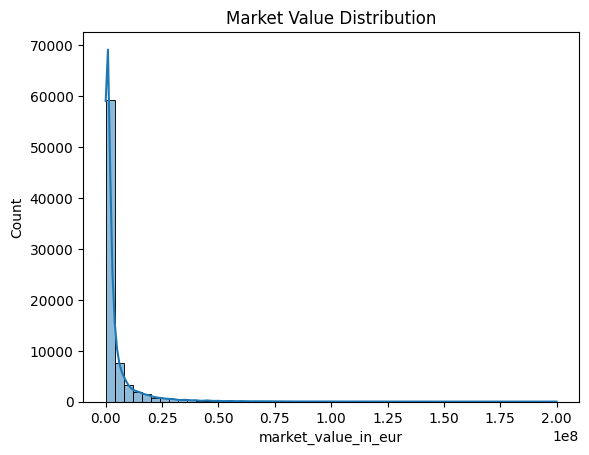

In [41]:
sns.histplot(df_first_dataset["market_value_in_eur"], bins=50, kde=True)
plt.title("Market Value Distribution")
plt.show()


In [42]:
num_cols = [
    'age', 'height_in_cm', 'minutes_played', 'goals', 'assists',
    'yellow_cards', 'red_cards', 'goals_per_minute', 'assists_per_minute'
]


In [43]:
low_card_cat_cols = ['position', 'foot']


In [44]:
high_card_cat_cols = ['country_of_citizenship', 'season', 'domestic_competition_id']


In [45]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd


In [ ]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.freqs = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        for col in X.columns:
            freq = X[col].value_counts(normalize=True)
            self.freqs[col] = freq
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        X_copy = X.copy()
        for col in X.columns:
            X_copy[col] = X_copy[col].map(self.freqs[col]).fillna(0)
        return X_copy

In [47]:
# Numerical
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Low-cardinality categorical
low_card_cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# High-cardinality categorical
high_card_cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('freq_encode', FrequencyEncoder())
])

# Final preprocessor
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('low_cat', low_card_cat_transformer, low_card_cat_cols),
    ('high_cat', high_card_cat_transformer, high_card_cat_cols)
])


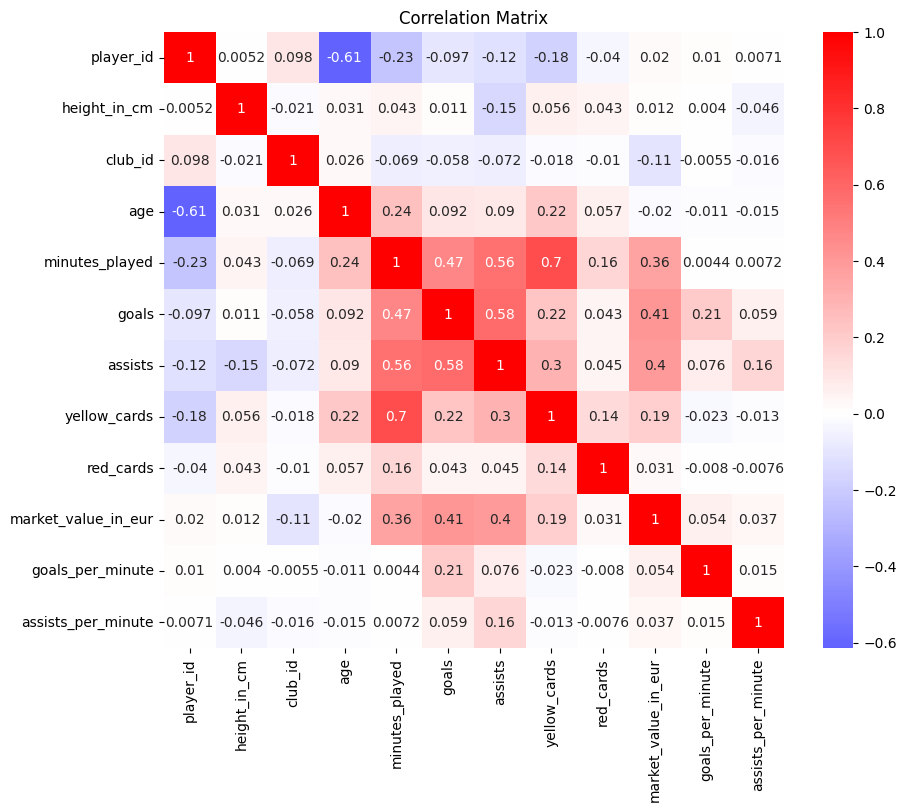

,feature_1,feature_2,correlation,absolute_correlation
88,yellow_cards,minutes_played,0.695749,0.695749
55,minutes_played,yellow_cards,0.695749,0.695749
3,player_id,age,-0.614732,0.614732
36,age,player_id,-0.614732,0.614732
77,assists,goals,0.582536,0.582536
66,goals,assists,0.582536,0.582536
54,minutes_played,assists,0.556019,0.556019
76,assists,minutes_played,0.556019,0.556019
64,goals,minutes_played,0.474204,0.474204
53,minutes_played,goals,0.474204,0.474204


In [48]:
# Pearson correlation matrix
correlation_matrix = df_first_dataset.select_dtypes(include='number').corr()

# Heatmap (optional for visualization)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='bwr', center=0)
plt.title("Correlation Matrix")
plt.show()

# flatten like in the lecture
corr_df = correlation_matrix.stack().reset_index()
corr_df.columns = ['feature_1', 'feature_2', 'correlation']

# Remove self-correlations
corr_df = corr_df[corr_df['feature_1'] != corr_df['feature_2']]

# Add absolute correlation
corr_df['absolute_correlation'] = np.abs(corr_df['correlation'])

# Sort and show top 10
top_corr = corr_df.sort_values(by='absolute_correlation', ascending=False).head(10)
display(top_corr)

In [49]:
import numpy as np

df_model = df_first_dataset.copy()

# filtering
df_model = df_model[df_model['market_value_in_eur'] < 1e8]  # Remove Messi/Neymar-like outliers

# Define the target variable (log1p for skew)
y = np.log1p(df_model['market_value_in_eur'])


X = df_model.drop(columns=[
    'market_value_in_eur',
    'player_id',
    'player_name',
    'club_id',
    'club_name',
    'first_game_date',
    'last_game_date'
])


In [50]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score


models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=10000),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}


results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    scores = cross_val_score(pipe, X, y, cv=5, scoring='r2')
    results[name] = scores
    print(f"{name} R² scores: {scores}")
    print(f"{name} Mean R²: {scores.mean():.4f}\n")


/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warning

Linear R² scores: [0.24420331 0.39185161 0.45538851 0.47172238 0.39463025]
Linear Mean R²: 0.3916



/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warning

Ridge R² scores: [0.24813906 0.39270725 0.45184163 0.46537624 0.39732052]
Ridge Mean R²: 0.3911



/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warning

Lasso R² scores: [0.14146847 0.21326628 0.24367956 0.2742036  0.28346149]
Lasso Mean R²: 0.2312



/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warning

Random Forest R² scores: [0.57499454 0.63279756 0.63686577 0.66048117 0.56886621]
Random Forest Mean R²: 0.6148



In [51]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [52]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

final_model = RandomForestRegressor(n_estimators=100, random_state=42)

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', final_model)
])


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)

print("R² on test set:", r2_score(y_test, y_pred))
rmse = mean_squared_error(y_test, y_pred) ** 0.5  # manually take sqrt
print("RMSE on test set:", rmse)


/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


R² on test set: 0.667014500837422
RMSE on test set: 0.865611211639575


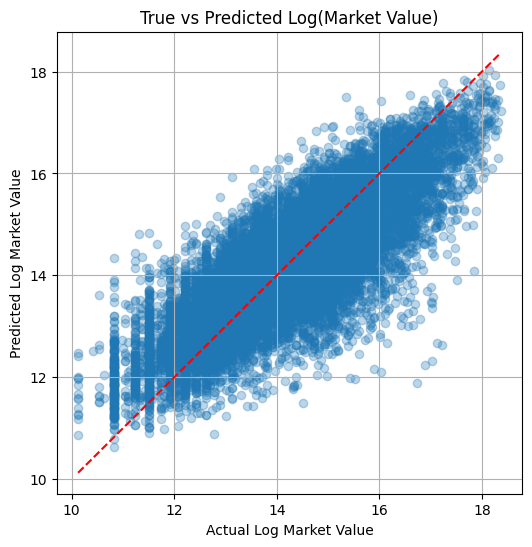

In [54]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')
plt.xlabel("Actual Log Market Value")
plt.ylabel("Predicted Log Market Value")
plt.title("True vs Predicted Log(Market Value)")
plt.grid(True)
plt.show()


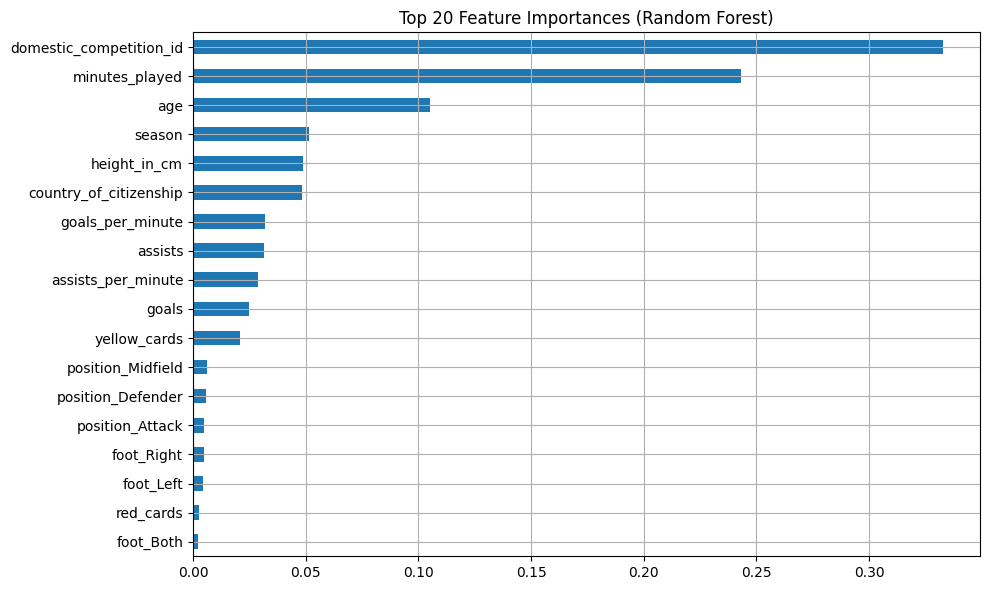

In [55]:
# direct import from chatgpt wanted to check what features are important.

import pandas as pd
import matplotlib.pyplot as plt

# Fit on the full training data
final_pipeline.fit(X_train, y_train)

# Step 1: Get the trained model (Random Forest)
rf_model = final_pipeline.named_steps['model']

# Step 2: Get the transformed feature names
# Numerical
num_features = num_cols

# Low-card categorical (OHE expands these)
ohe = preprocessor.named_transformers_['low_cat'].named_steps['encoder']
low_card_features = ohe.get_feature_names_out(low_card_cat_cols).tolist()

# High-card categorical (frequency encoded, so no expansion)
high_card_features = high_card_cat_cols

# Combine all feature names in the order they appear in transformed X
all_features = num_features + low_card_features + high_card_features

# Step 3: Get importances and zip with names
importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=all_features)

# Step 4: Plot top 20
plt.figure(figsize=(10, 6))
feat_importances.sort_values(ascending=False).head(20).plot(kind='barh')
plt.title("Top 20 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()
